# Endoscopy Dataset EDA

This notebook explores the dataset created from the image and annotation folders. It shows the dataset structure, label distribution, and a few example images with bounding boxes.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

sns.set_style("whitegrid")

train = pd.read_csv("../dataset/train.csv")
val = pd.read_csv("../dataset/val.csv")
test = pd.read_csv("../dataset/test.csv")

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)
print("\nTrain head:")
print(train.head())


Train shape: (9871, 8)
Validation shape: (2114, 8)
Test shape: (2118, 8)

Train head:
                 image_path                annotation_path  label     x1  \
0  Test\Images\124\0003.jpg  Test\Annotations\124\0003.txt      0    NaN   
1  Test\Images\147\0302.jpg  Test\Annotations\147\0302.txt      0    NaN   
2  Test\Images\123\0075.jpg  Test\Annotations\123\0075.txt      1  380.0   
3  Test\Images\115\0018.jpg  Test\Annotations\115\0018.txt      1  213.0   
4  Test\Images\140\0090.jpg  Test\Annotations\140\0090.txt      1   23.0   

      y1     x2     y2  source_folder  
0    NaN    NaN    NaN            124  
1    NaN    NaN    NaN            147  
2  125.0  445.0  216.0            123  
3  136.0  267.0  201.0            115  
4  198.0  162.0  463.0            140  



train label counts:
label
1    8147
0    1724
Name: count, dtype: int64


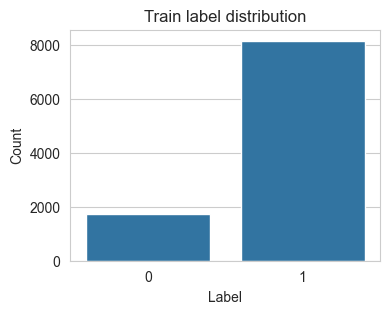


val label counts:
label
1    1745
0     369
Name: count, dtype: int64


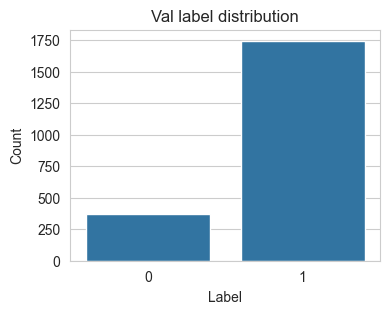


test label counts:
label
1    1747
0     371
Name: count, dtype: int64


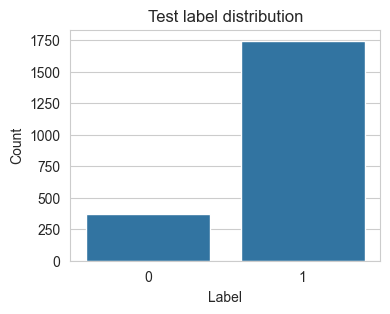

In [19]:
# Convert columns to numeric for coordinate analysis
for split in [train, val, test]:
    split["label"] = split["label"].astype(int)
    split["x1"] = pd.to_numeric(split["x1"], errors="coerce")
    split["y1"] = pd.to_numeric(split["y1"], errors="coerce")
    split["x2"] = pd.to_numeric(split["x2"], errors="coerce")
    split["y2"] = pd.to_numeric(split["y2"], errors="coerce")

for name, split in [("train", train), ("val", val), ("test", test)]:
    print(f"\n{name} label counts:")
    print(split["label"].value_counts(dropna=False))

    plt.figure(figsize=(4, 3))
    sns.countplot(data=split, x="label")
    plt.title(f"{name.capitalize()} label distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.show()


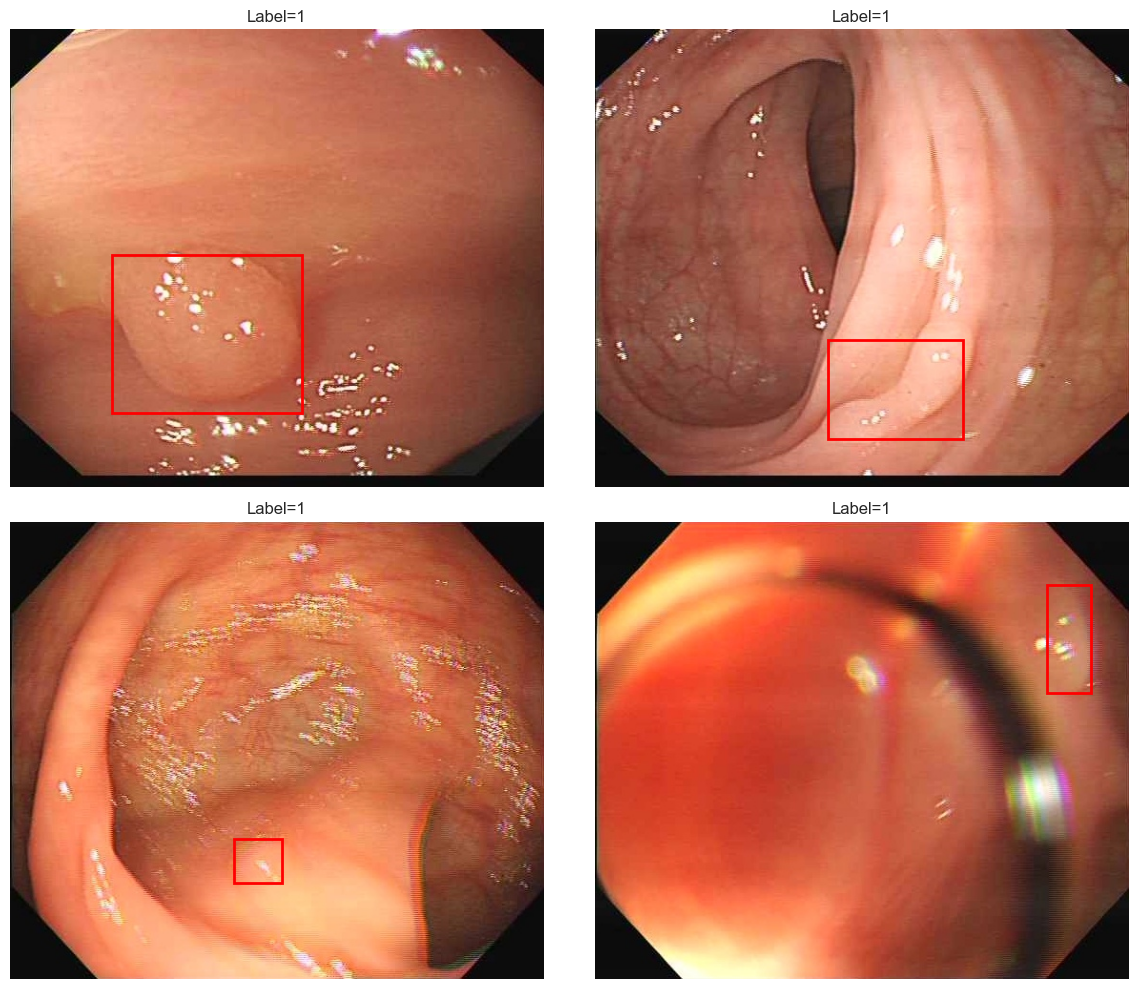

In [ ]:
sample = train.sample(4, random_state=42)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, row in zip(axes.flat, sample.itertuples()):
    img_path = Path(row.image_path)
    if not img_path.exists():
        img_path = Path("..") / img_path

    img = Image.open(img_path)
    ax.imshow(img)

    if row.label == 1:
        rect = patches.Rectangle(
            (row.x1, row.y1),
            row.x2 - row.x1,
            row.y2 - row.y1,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)

    ax.set_title(f"Label={row.label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Bounding box analysis

This section explores the size and spread of the annotated regions in the positive class.


             width       height           area
count  8147.000000  8147.000000    8147.000000
mean     96.599116   103.151467   13762.180189
std      67.673699    70.048781   20732.868238
min      12.000000    15.000000     340.000000
25%      49.000000    53.000000    2752.000000
50%      75.000000    79.000000    5888.000000
75%     123.000000   134.000000   16402.000000
max     519.000000   474.000000  240297.000000


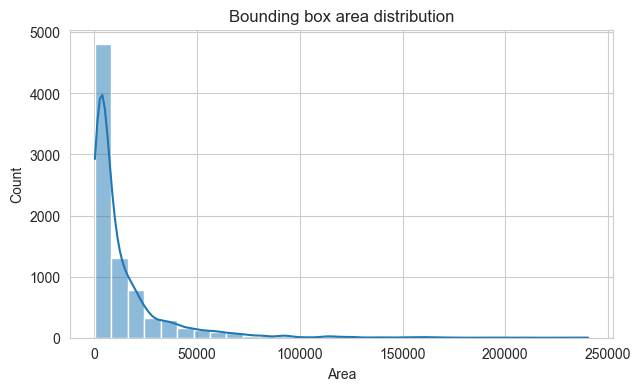

In [22]:
pos = train[train["label"] == 1].copy()
pos["width"] = pos["x2"] - pos["x1"]
pos["height"] = pos["y2"] - pos["y1"]
pos["area"] = pos["width"] * pos["height"]

print(pos[["width", "height", "area"]].describe())

plt.figure(figsize=(7, 4))
sns.histplot(pos["area"], bins=30, kde=True)
plt.title("Bounding box area distribution")
plt.xlabel("Area")
plt.ylabel("Count")
plt.show()


## Image size analysis

This section checks whether all images share a common resolution or if there is noticeable size variation across the dataset.


        width  height
count  9871.0  9871.0
mean    560.0   480.0
std       0.0     0.0
min     560.0   480.0
25%     560.0   480.0
50%     560.0   480.0
75%     560.0   480.0
max     560.0   480.0


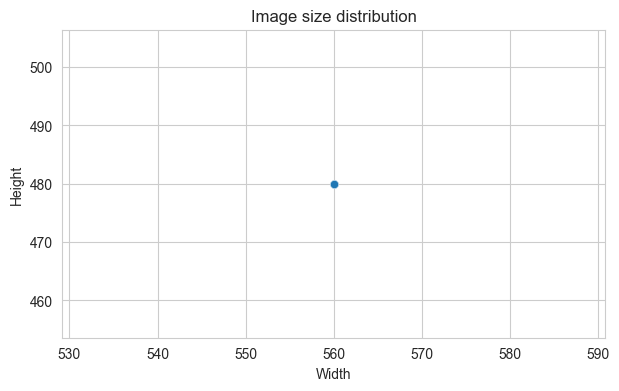

In [23]:
sizes = []
for row in train.itertuples():
    img_path = Path(row.image_path)
    if not img_path.exists():
        img_path = Path("..") / img_path
    with Image.open(img_path) as img:
        sizes.append((img.size[0], img.size[1]))

size_df = pd.DataFrame(sizes, columns=["width", "height"])
print(size_df.describe())

plt.figure(figsize=(7, 4))
sns.scatterplot(data=size_df, x="width", y="height", alpha=0.5)
plt.title("Image size distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()


## Bounding box position analysis

This plot shows where the object centers are located across the image canvas to reveal spatial bias in the annotations.


## Bounding box center-position analysis

This plot helps show whether the annotated object is consistently centered or spread across the frame.


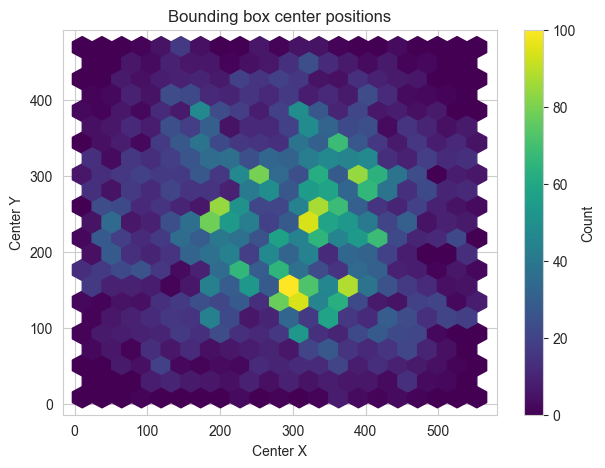

In [25]:
pos = train[train["label"] == 1].copy()
pos["center_x"] = (pos["x1"] + pos["x2"]) / 2
pos["center_y"] = (pos["y1"] + pos["y2"]) / 2

plt.figure(figsize=(7, 5))
plt.hexbin(pos["center_x"], pos["center_y"], gridsize=20, cmap="viridis")
plt.colorbar(label="Count")
plt.title("Bounding box center positions")
plt.xlabel("Center X")
plt.ylabel("Center Y")
plt.show()
